<a href="https://colab.research.google.com/github/bharath-0905/mlproject/blob/main/DBscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['KAGGLE_USERNAME']="Bharath20"
os.environ['kaggle_key']="KGAT_10c8f629b88da2dac16c940f033b02cc"

In [ ]:
!kaggle datasets download -d ankit8467/dataset-for-dbscan

Dataset URL: https://www.kaggle.com/datasets/ankit8467/dataset-for-dbscan
License(s): unknown
100% 39.3k/39.3k [00:00<00:00, 43.7MB/s]



In [ ]:
import zipfile
import os

zip_path="/content/dataset-for-dbscan.zip"
extract_path="extracted_file"

os.makedirs(extract_path,exist_ok=True)

with  zipfile.ZipFile(zip_path,'r')as zip_ref:
  zip_ref.extractall(extract_path)

print("File exctracted to:",extract_path)



File exctracted to: extracted_file


In [ ]:
import zipfile
import os

zip_path="/content/dataset-for-dbscan.zip"
extract_path="extracted_file"

os.makedirs(extract_path,exist_ok=True)

with  zipfile.ZipFile(zip_path,'r')as zip_ref:
  zip_ref.extractall(extract_path)

print("File exctracted to:",extract_path)



File exctracted to: extracted_file


In [ ]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# Step 2: Load dataset
data = pd.read_csv("/content/extracted_file/Clustering_gmm (2).csv")
print("First 5 rows:\n", data.head())

First 5 rows:
       Weight      Height
0  67.062924  176.086355
1  68.804094  178.388669
2  60.930863  170.284496
3  59.733843  168.691992
4  65.431230  173.763679


In [ ]:
# ==========================================
# Step 5: Dataset Information
# ==========================================

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  500 non-null    float64
 1   Height  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [ ]:
# ==========================================
# Step 6: Dataset Shape
# ==========================================

print("Rows :", data.shape[0])
print("Columns :", data.shape[1])

Rows : 500
Columns : 2


In [ ]:
# ==========================================
# Step 7: Missing Values
# ==========================================

data.isnull().sum()

,0
Weight,0
Height,0


In [ ]:
# ==========================================
# Step 8: Duplicate Values
# ==========================================

print("Duplicate Rows :", data.duplicated().sum())

Duplicate Rows : 0


In [ ]:
# ==========================================
# Step 9: Statistical Summary
# ==========================================

data.describe()

,Weight,Height
count,500.000000,500.000000
mean,61.270240,169.515781
std,5.196976,4.805095
min,50.433644,160.182164
25%,57.772791,166.607599
50%,61.961518,169.726252
75%,65.439332,172.837284
max,70.700456,178.894770


In [ ]:
# ==========================================
# Step 10: Feature Selection
# ==========================================

X = data[['Weight','Height']]

X.head()

,Weight,Height
0,67.062924,176.086355
1,68.804094,178.388669
2,60.930863,170.284496
3,59.733843,168.691992
4,65.431230,173.763679


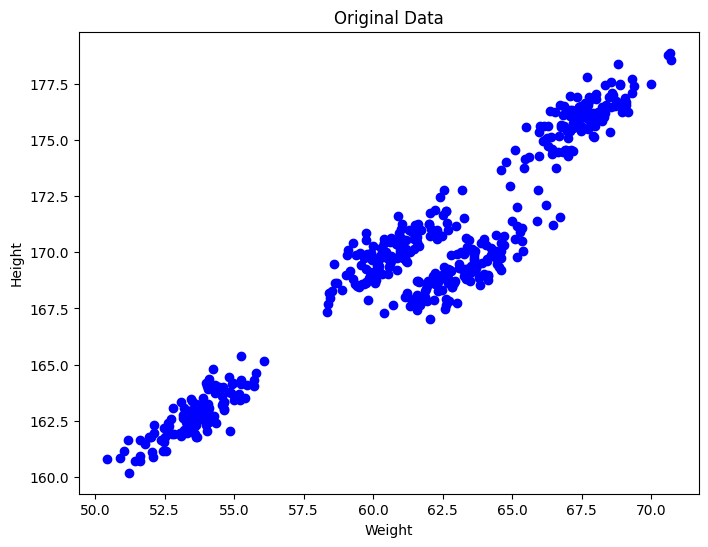

In [ ]:
# ==========================================
# Step 11: Original Data Visualization
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    X['Weight'],
    X['Height'],
    color='blue'
)

plt.title("Original Data")

plt.xlabel("Weight")

plt.ylabel("Height")

plt.show()

In [ ]:
# ==========================================
# Step 12: Feature Scaling
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

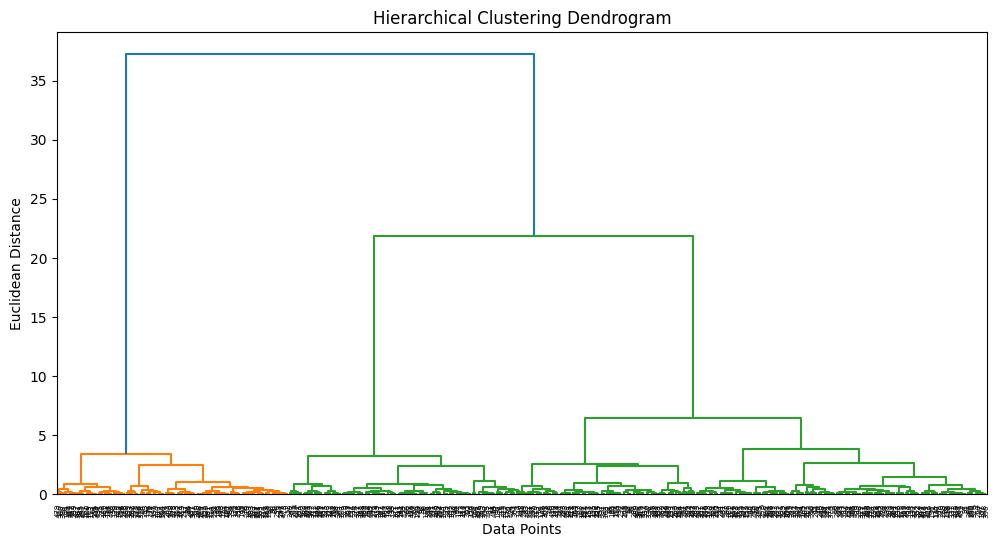

In [ ]:
# ==========================================
# Step 13: Dendrogram
# ==========================================
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Euclidean Distance")

plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
# ==========================================
# Step 14: Train Model
# ==========================================

hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

clusters = hc.fit_predict(X_scaled)

In [ ]:
# ==========================================
# Step 15: Add Cluster Column
# ==========================================

data["Cluster"] = clusters

data.head()

,Weight,Height,Cluster
0,67.062924,176.086355,2
1,68.804094,178.388669,2
2,60.930863,170.284496,0
3,59.733843,168.691992,0
4,65.431230,173.763679,2


In [ ]:
# ==========================================
# Step 16: Cluster Count
# ==========================================

print(data["Cluster"].value_counts())

Cluster
0    251
1    125
2    124
Name: count, dtype: int64


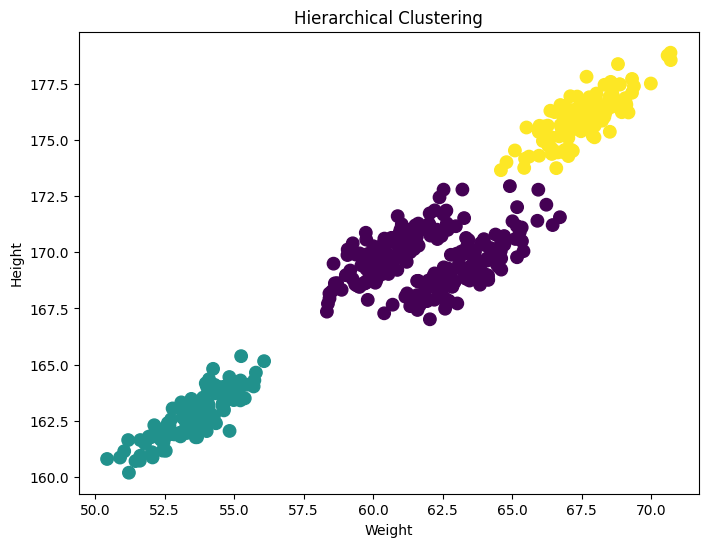

In [ ]:
# ==========================================
# Step 17: Cluster Visualization
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    data["Weight"],
    data["Height"],
    c=data["Cluster"],
    cmap="viridis",
    s=80
)

plt.title("Hierarchical Clustering")

plt.xlabel("Weight")

plt.ylabel("Height")

plt.show()

In [ ]:
# ==========================================
# Step 18: Cluster Analysis
# ==========================================

data.groupby("Cluster").mean()

,Weight,Height
Cluster,,
0,61.993490,169.669234
1,53.600298,162.764782
2,67.538036,176.010602
